# Agent
In this notebook, we're going to build a simple agent using using LangGraph.
This notebook is part of the Hugging Face Agents Course, a free course from beginner to expert, where you learn to build Agents.



As seen in the Unit 1, an agent needs 3 steps as introduced in the ReAct architecture : ReAct, a general agent architecture.

act - let the model call specific tools
observe - pass the tool output back to the model
reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

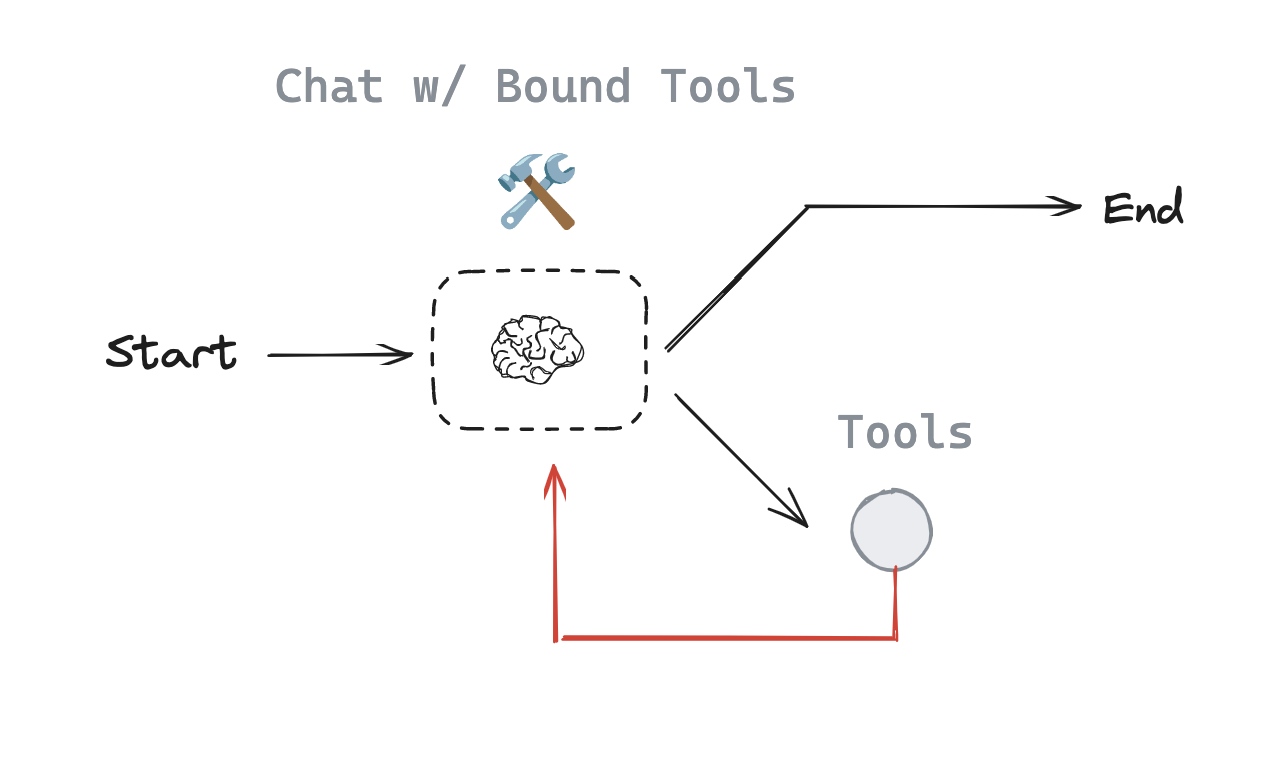

## Document Analysis Graph

A document analysis agent using LangGraph that can:
1. Process image documents
2. Extract text using vision models (VLM)
3. Perform calculations with tools
4. Analyze content and provide summaries
5. Execute specific instructions related to documents

The agent follows the **ReAct pattern** (Reason → Act → Observe → Repeat).

## The Butler’s Workflow
The workflow we’ll build follows this structured schema:

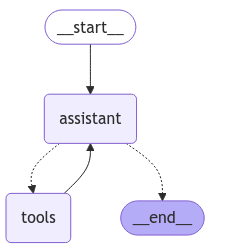

In [1]:
!pip install langgraph langchain_core langchain_huggingface langchain-anthropic


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import base64
from typing import List, TypedDict, Annotated, Optional
from langchain_anthropic import ChatAnthropic
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

In [4]:
import anthropic
import os
from dotenv import load_dotenv

load_dotenv(dotenv_path="../.env", override=True)
api_key=os.environ.get("ANTHROPIC_API_KEY")

## Agent State

`AnyMessage` is a LangChain class for messages.  
`add_messages` is an **operator** that appends new messages instead of overwriting state — a key LangGraph concept.

In [5]:
class AgentState(TypedDict):
    # The document provided
    input_file: Optional[str]  # Contains file path (PDF/PNG)
    messages: Annotated[list[AnyMessage], add_messages]

## Tools

Two tools are provided to the agent:
- `extract_text`: reads an image and extracts its text via a vision-capable LLM (claude-sonnet-4.6)
- `divide`: simple division — demonstrates how regular Python functions become agent tools

In [6]:
vision_llm = ChatAnthropic(model="claude-sonnet-4-6")

def extract_text(img_path: str) -> str:
    """
    Extract text from an image file using Claude's vision capability.
    """
    all_text = ""
    try:
        with open(img_path, "rb") as image_file:
            image_bytes = image_file.read()

        image_base64 = base64.b64encode(image_bytes).decode("utf-8")

        message = [
            HumanMessage(
                content=[
                    {
                        "type": "text",
                        "text": (
                            "Extract all the text from this image. "
                            "Return only the extracted text, no explanations."
                        ),
                    },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{image_base64}"
                        },
                    },
                ]
            )
        ]

        response = vision_llm.invoke(message)
        all_text += response.content + "\n\n"
        return all_text.strip()

    except Exception as e:
        error_msg = f"Error extracting text: {str(e)}"
        print(error_msg)
        return ""


def divide(a: int, b: int) -> float:
    """Divide a and b."""
    return a / b


tools = [divide, extract_text]

llm = ChatAnthropic(model="claude-sonnet-4-6")
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

## Assistant Node

The `assistant` node is the core reasoning step. It receives the current state,
injects a system prompt describing available tools and the loaded image, then
invokes Claude (with tools bound).

In [7]:
def assistant(state: AgentState):
    textual_description_of_tool = """
extract_text(img_path: str) -> str:
    Extract text from an image file using Claude's vision capability.
    Args:
        img_path: A local image file path (string).
    Returns:
        A single string containing the extracted text.

divide(a: int, b: int) -> float:
    Divide a and b.
"""
    image = state["input_file"]
    sys_msg = SystemMessage(
        content=(
            f"You are a helpful butler named Alfred that serves Mr. Wayne and Batman. "
            f"You can analyse documents and run computations with provided tools:\n"
            f"{textual_description_of_tool}\n"
            f"You have access to some optional images. Currently the loaded image is: {image}"
        )
    )

    return {
        "messages": [llm_with_tools.invoke([sys_msg] + state["messages"])],
        "input_file": state["input_file"],
    }

## Build the Graph

The graph structure:
START → assistant → (tools_condition) → tools → assistant → ... → END

- `tools_condition` routes to `tools` if Claude called a tool, otherwise to `END`
- The `tools → assistant` edge creates the **ReAct loop**

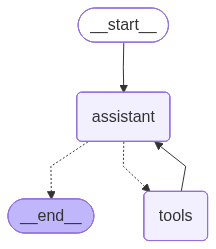

In [9]:
builder = StateGraph(AgentState)

# Nodes
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))

# Edges
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,  # routes to "tools" or END
)
builder.add_edge("tools", "assistant")

react_graph = builder.compile()

# Visualize the graph
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

## Example 1: Simple Calculation

Invoke the agent with a plain math request to verify tool use is working.

In [10]:
messages = [HumanMessage(content="Divide 6790 by 5")]
result = react_graph.invoke({"messages": messages, "input_file": None})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Divide 6790 by 5
================================== Ai Message ==================================

[{'text': 'Sure! Let me compute that for you right away.', 'type': 'text'}, {'id': 'toolu_0195LhRufXWnhr8FsPAbMTKu', 'caller': {'type': 'direct'}, 'input': {'a': 6790, 'b': 5}, 'name': 'divide', 'type': 'tool_use'}]
Tool Calls:
  divide (toolu_0195LhRufXWnhr8FsPAbMTKu)
 Call ID: toolu_0195LhRufXWnhr8FsPAbMTKu
  Args:
    a: 6790
    b: 5
================================= Tool Message =================================
Name: divide

1358.0
================================== Ai Message ==================================

The result of dividing **6790** by **5** is **1358**. Is there anything else I can assist you with, Master Wayne? 🦇


## Example 2: Document Analysis from Image

Pass an image path via `input_file`. Claude will call `extract_text` on it,
then reason over the extracted content to answer the question.

> Make sure `Batman_training_and_meals.png` (or your own image) is in the working directory.

In [11]:
messages = [
    HumanMessage(
        content=(
            "According to the note provided by Mr. Wayne in the provided images. "
            "What's the list of items I should buy for the dinner menu?"
        )
    )
]
result = react_graph.invoke({
    "messages": messages,
    "input_file": "Batman_training_and_meals.png"  # replace with your image path
})

for m in result["messages"]:
    m.pretty_print()

Task was destroyed but it is pending!
task: <Task pending name='Task-190' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/clean_zaid/Documents/Home/Backups/BOOKS/Trillionaire/Python/jupyter-notebooks/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-191' coro=<Kernel.shell_main() running at /Users/clean_zaid/Documents/Home/Backups/BOOKS/Trillionaire/Python/jupyter-notebooks/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/clean_zaid/Documents/Home/Backups/BOOKS/Trillionaire/Python/jupyter-notebooks/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/clean_zaid/.pyenv/versions/3.12.4/lib/python3.12/typing.py:407: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def _eval_type(t, globalns, localns, type_params=None, *, recursive_guard=frozenset()):
Task was destroyed but it is pendin

================================ Human Message =================================

According to the note provided by Mr. Wayne in the provided images. What's the list of items I should buy for the dinner menu?
================================== Ai Message ==================================

[{'text': 'Of course! Let me extract the text from the provided image right away to find the dinner menu details!', 'type': 'text'}, {'id': 'toolu_01UZqEbsod9oPZpWwWCJnzot', 'caller': {'type': 'direct'}, 'input': {'img_path': 'Batman_training_and_meals.png'}, 'name': 'extract_text', 'type': 'tool_use'}]
Tool Calls:
  extract_text (toolu_01UZqEbsod9oPZpWwWCJnzot)
 Call ID: toolu_01UZqEbsod9oPZpWwWCJnzot
  Args:
    img_path: Batman_training_and_meals.png
================================= Tool Message =================================
Name: extract_text

**TRAINING SCHEDULE**
**For the week of 2/20-2/26**

**SUNDAY 2/20**
MORNING
30 minute jog
30 minute meditation

EVENING
clean and jerk lifts – 3 reps

This is a classic Jupyter + asyncio conflict. The Jupyter kernel runs its own event loop, and LangGraph's .invoke() clashes with it. The fix is to  you can call the async version directly:


In [12]:
import asyncio

messages = [
    HumanMessage(
        content=(
            "According to the note provided by Mr. Wayne in the provided images. "
            "What's the list of items I should buy for the dinner menu?"
        )
    )
]

result = await react_graph.ainvoke({
    "messages": messages,
    "input_file": "Batman_training_and_meals.png"  # replace with your image path
})

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

According to the note provided by Mr. Wayne in the provided images. What's the list of items I should buy for the dinner menu?
================================== Ai Message ==================================

[{'text': 'Of course! Let me extract the text from the provided image right away!', 'type': 'text'}, {'id': 'toolu_01WxXwHUgYfsQM6fSi7KNFDc', 'caller': {'type': 'direct'}, 'input': {'img_path': 'Batman_training_and_meals.png'}, 'name': 'extract_text', 'type': 'tool_use'}]
Tool Calls:
  extract_text (toolu_01WxXwHUgYfsQM6fSi7KNFDc)
 Call ID: toolu_01WxXwHUgYfsQM6fSi7KNFDc
  Args:
    img_path: Batman_training_and_meals.png
================================= Tool Message =================================
Name: extract_text

**TRAINING SCHEDULE**
**For the week of 2/20-2/26**

**SUNDAY 2/20**
MORNING
30 minute jog
30 minute meditation

EVENING
clean and jerk lifts – 3 reps/8 sets. 262 lbs.
5 sets metabol

## Key Takeaways

| Concept | Detail |
|---|---|
| `AgentState` | Typed dict that carries messages + optional file path across nodes |
| `add_messages` operator | Appends messages instead of overwriting — preserves history |
| `bind_tools` | Connects Python functions to Claude as callable tools |
| `tools_condition` | Conditional edge that checks whether Claude issued a tool call |
| ReAct loop | `assistant → tools → assistant` repeats until no tool call is made |
| Vision tool | `claude-sonnet-4-6` reads image bytes encoded as base64 for text extraction |